In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import torch
import torch.nn as nn
import torch.optim as optim


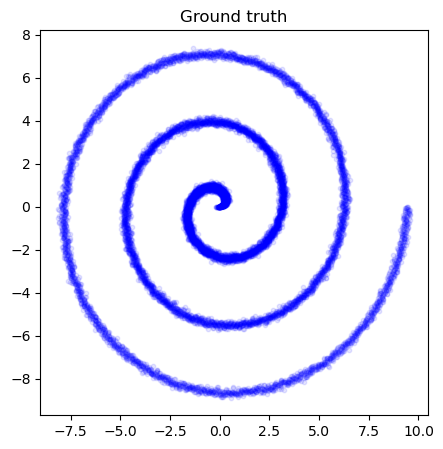

In [148]:
# 1. Spin around 3 times (3 * 2*pi)
theta = np.linspace(0, 3 * 2 * np.pi, 10000)

# Add your noise
noise = np.random.normal(0, 0.1, 10000)

# 2. Radius grows as theta grows. 
# Multiplying by 0.5 controls how tightly coiled the spiral is.
r = (0.5 * theta) + noise 

spiral_x = np.cos(theta) * r
spiral_y = np.sin(theta) * r

ground_truth = np.column_stack([spiral_x, spiral_y])

# CRITICAL FOR YOUR DRIFTING MODEL: 
# Because the spiral gets quite wide at the ends, always normalize it 
# so your neural network doesn't explode when calculating distances!
ground_truth = (ground_truth - np.mean(ground_truth, axis=0)) / np.std(ground_truth, axis=0)


plt.figure(figsize=(5, 5)) 
plt.title("Ground truth")
plt.scatter(spiral_x, spiral_y, s=10, alpha=0.1, color = 'blue')
plt.show()

ground_truth = np.array([list(pair) for pair in zip(spiral_x, spiral_y)])
ground_truth = torch.from_numpy(ground_truth).to(torch.float32).to(device)
ground_truth = (ground_truth - torch.min(ground_truth)) / (torch.max(ground_truth) - torch.min(ground_truth))

In [149]:
# define the model architecture for f 
class neuralNet(nn.Module):
    def __init__(self):
        # Call the constructor of the parent class (nn.Module)
        super(neuralNet, self).__init__()

        self.input = nn.Linear(32, 258)
        self.initialRelu = nn.SiLU()
        self.layer1 = nn.Linear(258, 258)
        self.relu1 = nn.SiLU()
        self.layer2 = nn.Linear(258, 258)
        self.relu2 = nn.SiLU()
        # self.layer3 = nn.Linear(258, 258)
        # self.relu3 = nn.SiLU()
        self.output = nn.Linear(258, 2)

    def forward(self, v):
        " v is vector dim 2 (x, y)"
        v = self.input(v)
        v = self.initialRelu(v)
        v = self.layer1(v)
        v = self.relu1(v)
        v = self.layer2(v)
        v = self.relu2(v)
        # v = self.layer3(v)
        # v = self.relu3(v)
        v = self.output(v)
        return v
        

# Plain drifting

In [293]:
def softmax(logits, dim):
    logits = logits - logits.max(dim=dim, keepdim=True).values
    exp = torch.exp(logits)
    return exp / exp.sum(dim=dim, keepdim=True)

def compute_V(y_pos, y_neg, T=1.0, eps=1e-8):
    N = y_neg.shape[0]
    points = torch.cat([y_neg, y_pos],dim=0).to(torch.float32)

    dist = torch.cdist(y_neg, points)
    dist[:, :N] += torch.eye(N, device=dist.device) * 1e6 # So that the point you are standing doesn't influence, really important

    logits = -dist/T # this is log(k(x,y)) for every pair
    A_row = softmax(logits, dim=1)  # Equivalent to Z normalization, Zq and Zp at the same time
    #A_col = softmax(logits, dim=0)  # normalize each column (target) across particles
    #A = torch.sqrt(A_row * A_col)
    A = A_row
    
    A_neg = A[:, :N]
    A_pos = A[:, N:]

    W_pos = A_pos * A_neg.sum(axis=1, keepdims=True) # k(x,y+) scaled by total neg mass
    W_neg = A_neg * A_pos.sum(axis=1, keepdims=True) # k(x,y-) scaled by total pos mass

    drift_pos = W_pos @ y_pos
    drift_neg = W_neg @ y_neg
    V = drift_pos - drift_neg
    
    return V

def loss_function(generated, y_pos): 
    with torch.no_grad():
        V = compute_V(y_pos, generated)
        frozen_targets = (generated + V).detach().clone()
    return mse(generated, frozen_targets)

In [168]:
# train and keep record of some iterations to graph
f = neuralNet()
mse = nn.MSELoss()
optimizer = optim.AdamW(f.parameters(), lr=0.001)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)

def training_loop(num_epochs, batch_size = 1000):
    f.to(device)
    train_losses = []
    print("Training stared")
    special_iterations =  [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]
    q_evolution = []
    
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        f.train()
        optimizer.zero_grad()

        noise_indices = np.random.choice(10000, batch_size, replace=False)
        real_indices = np.random.choice(len(ground_truth), batch_size, replace=False)
        gaussian_batch = gaussian[noise_indices]
        truth_batch = ground_truth[real_indices]

        generated = f(gaussian_batch)
        loss =  loss_function(generated, truth_batch) 
        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        if epoch in special_iterations:
            q_evolution.append(generated.detach().cpu().numpy())
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.6f}")
            
    print("Finished")
    return f, train_losses, q_evolution
    

In [169]:
f_trained, losses, evolution = training_loop(5000)

Training stared
Epoch [0/5000], Loss: 0.000000
Epoch [100/5000], Loss: 0.000020
Epoch [200/5000], Loss: 0.000020
Epoch [300/5000], Loss: 0.000019
Epoch [400/5000], Loss: 0.000017
Epoch [500/5000], Loss: 0.000016
Epoch [600/5000], Loss: 0.000015
Epoch [700/5000], Loss: 0.000014
Epoch [800/5000], Loss: 0.000013
Epoch [900/5000], Loss: 0.000011
Epoch [1000/5000], Loss: 0.000011
Epoch [1100/5000], Loss: 0.000011
Epoch [1200/5000], Loss: 0.000009
Epoch [1300/5000], Loss: 0.000009
Epoch [1400/5000], Loss: 0.000009
Epoch [1500/5000], Loss: 0.000007
Epoch [1600/5000], Loss: 0.000007
Epoch [1700/5000], Loss: 0.000007
Epoch [1800/5000], Loss: 0.000007
Epoch [1900/5000], Loss: 0.000006
Epoch [2000/5000], Loss: 0.000006
Epoch [2100/5000], Loss: 0.000005
Epoch [2200/5000], Loss: 0.000004
Epoch [2300/5000], Loss: 0.000004
Epoch [2400/5000], Loss: 0.000004
Epoch [2500/5000], Loss: 0.000004
Epoch [2600/5000], Loss: 0.000004
Epoch [2700/5000], Loss: 0.000004
Epoch [2800/5000], Loss: 0.000003
Epoch [290

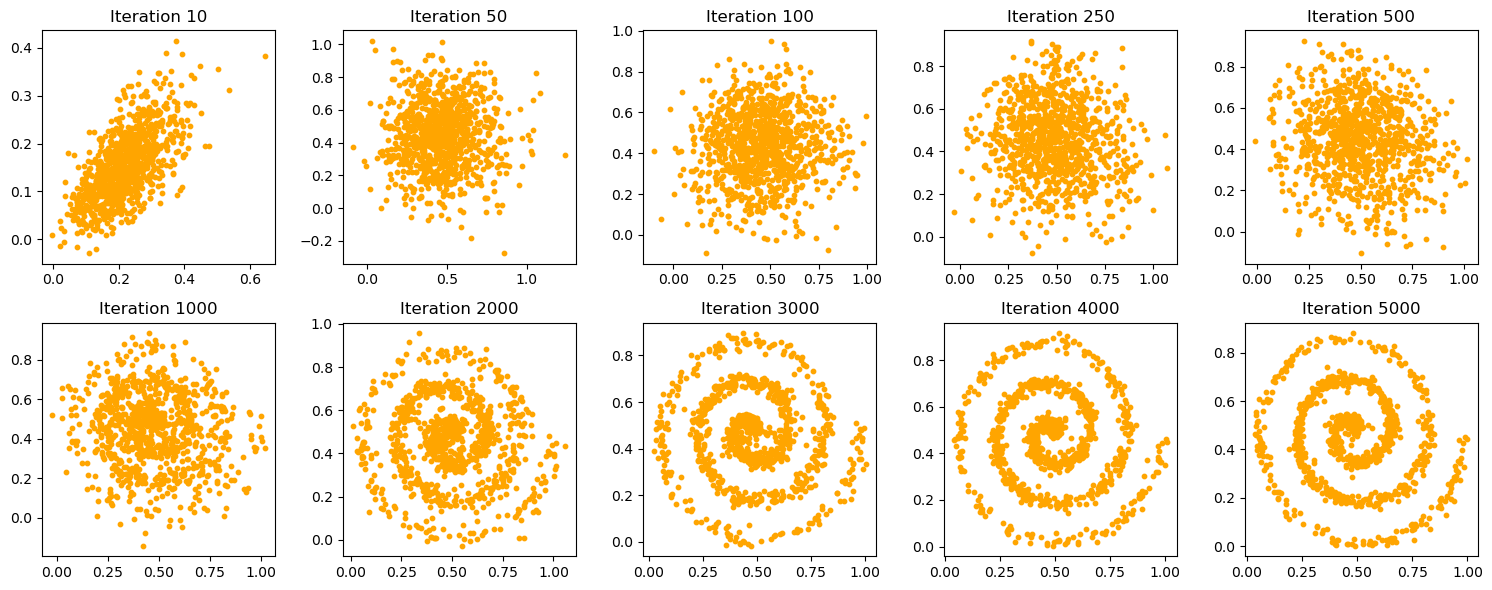

In [170]:
# Starts working nice with T = 0.02
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [5]:
print("GPU Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU Available: True
Device Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


# W-flow

In [171]:
def sinkhorn(source, target, eps, steps):
    n = source.shape[0]
    m = target.shape[0]
    a = torch.full((n,),1.0/n, device=source.device)
    b = torch.full((m,),1.0/m, device=source.device)
    cost = 0.5 * torch.cdist(source, target)**2

    kernel = torch.exp(-cost/eps)
    u = torch.ones(n,device=source.device)
    v = torch.ones(m, device=source.device)
    for i in range(steps):
        u = a / (kernel @ v+ 1e-12)
        v = b / (kernel.T @ u+ 1e-12)
        
    # plan = torch.diag(u) @ kernel @ torch.diag(v)
    plan = u.unsqueeze(1) * kernel * v.unsqueeze(0)
    t = (plan @ target) / a.unsqueeze(1)
    return t

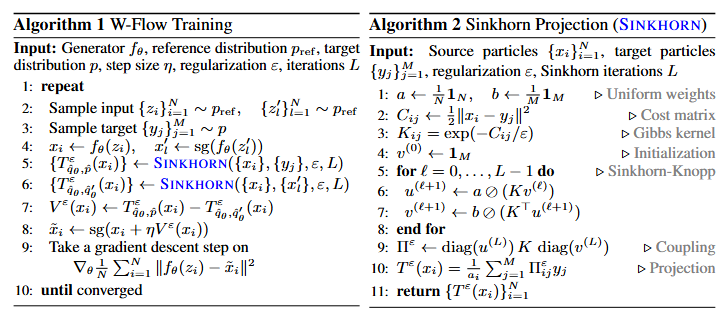

In [207]:
def training(f, reference, target, stepSize, eps, num_epochs, batch_size = 1000, sinkhorn_iter=100):
    f.to(device)
    optimizer = optim.AdamW(f.parameters(), lr=0.001)
    train_losses = []
    print("Training stared")
    special_iterations =  [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]
    q_evolution = []
    
    for epoch in range(num_epochs+1):
        epoch_loss = 0.0
        f.train()
        optimizer.zero_grad()

        # sample input
        noise_indices = np.random.choice(len(reference), batch_size * 2 , replace=False)
        gaussian_batchA = reference[noise_indices[:len(noise_indices)//2]]
        gaussian_batchB = reference[noise_indices[len(noise_indices)//2:]]

        # sample target
        real_indices = np.random.choice(len(target), batch_size, replace=False)
        truth_batch = target[real_indices]

        x = f(gaussian_batchA)
        with torch.no_grad():
            xP = f(gaussian_batchB)
            
        t = sinkhorn(x, truth_batch, eps, sinkhorn_iter)
        tP = sinkhorn(x, xP, eps, sinkhorn_iter)
        with torch.no_grad():
            field = t - tP
            x_hat = x + stepSize * field
            
        
        loss = torch.mean(torch.sum((x - x_hat)**2, dim=1))
        loss.backward()
        optimizer.step()
        
        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        if epoch in special_iterations:
            q_evolution.append(x.detach().cpu().numpy())
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss:.10f}")
            
    print("Finished")
    return f, train_losses, q_evolution
    

In [208]:
f = neuralNet()
nn.init.orthogonal_(f.output.weight)
nn.init.zeros_(f.output.bias)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
f_trained, losses, evolution = training(f, gaussian, ground_truth, 0.001 , 0.001, 5000)

Training stared
Epoch [0/5000], Loss: 0.0000000040
Epoch [100/5000], Loss: 0.0000000043
Epoch [200/5000], Loss: 0.0000000033
Epoch [300/5000], Loss: 0.0000000028
Epoch [400/5000], Loss: 0.0000000098
Epoch [500/5000], Loss: 0.0000000030
Epoch [600/5000], Loss: 0.0000000030
Epoch [700/5000], Loss: 0.0000000023
Epoch [800/5000], Loss: 0.0000000022
Epoch [900/5000], Loss: 0.0000000019
Epoch [1000/5000], Loss: 0.0000000024
Epoch [1100/5000], Loss: 0.0000000025
Epoch [1200/5000], Loss: 0.0000000031
Epoch [1300/5000], Loss: 0.0000000018
Epoch [1400/5000], Loss: 0.0000000029
Epoch [1500/5000], Loss: 0.0000000034
Epoch [1600/5000], Loss: 0.0000000020
Epoch [1700/5000], Loss: 0.0000000017
Epoch [1800/5000], Loss: 0.0000000021
Epoch [1900/5000], Loss: 0.0000000025
Epoch [2000/5000], Loss: 0.0000000023
Epoch [2100/5000], Loss: 0.0000000020
Epoch [2200/5000], Loss: 0.0000000029
Epoch [2300/5000], Loss: 0.0000000038
Epoch [2400/5000], Loss: 0.0000000031
Epoch [2500/5000], Loss: 0.0000000021
Epoch [2

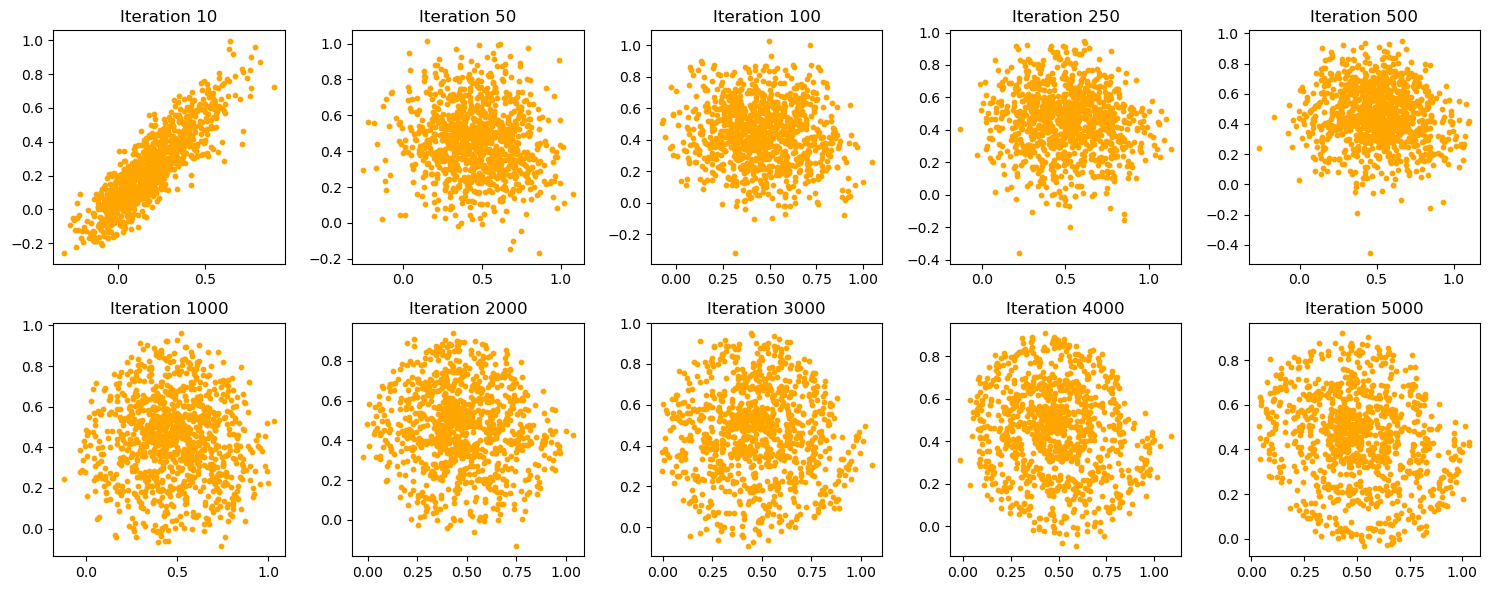

In [209]:
# step and eps: 0.001 , 0.001
its =  [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

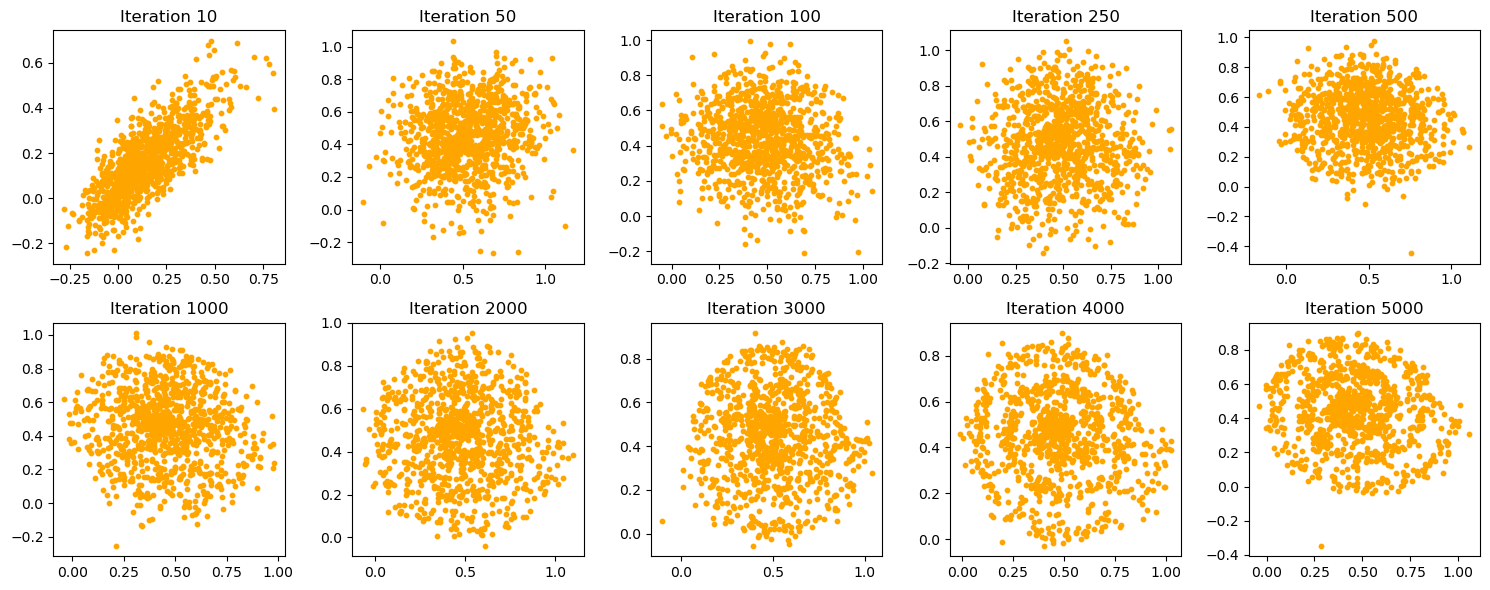

In [197]:
# step size 0.01 and eps 0.001
its =  [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

In [ ]:
#  Start by implementing Real NVP from scratch. It's ~100 lines of PyTorch, and the affine coupling layer is the core building block you'll reuse everywhere.

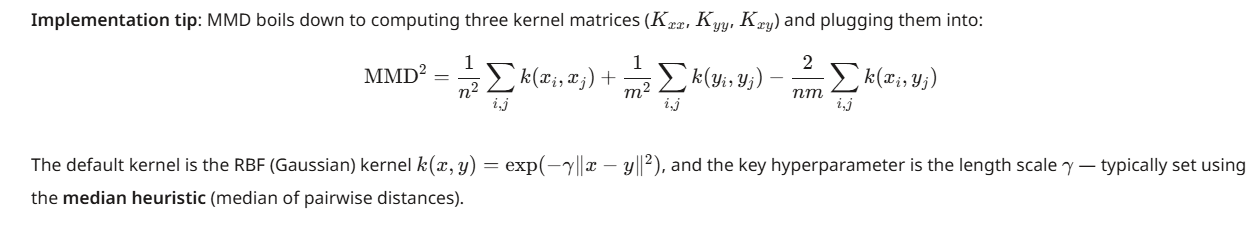

In [214]:
def rbf_kernel(x, y, sigmas=(0.5, 1.0, 2.0, 4.0, 8.0, 16.0)):
    """Sum of RBF kernels at several bandwidths, evaluated on all pairs of x, y."""
    dist = torch.cdist(x, y) ** 2
    k = 0.0
    for s in sigmas:
        k = k + torch.exp(-dist / (2 * s ** 2))
    return k

def mmd_loss(generated, y_pos, sigmas=(0.05, 0.1, 0.25, 0.5, 1.0, 2.0)):
    K_xx = rbf_kernel(generated, generated, sigmas)
    K_yy = rbf_kernel(y_pos, y_pos, sigmas)
    K_xy = rbf_kernel(generated, y_pos, sigmas)
    return K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()

In [215]:
def training_loop_mmd(num_epochs, batch_size=1000):
    f = neuralNet().to(device)
    optimizer = optim.AdamW(f.parameters(), lr=0.001)
    # gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
    train_losses = []
    print("Training stared")
    special_iterations = [10, 50, 500, 1000, 2000, 3000, 4000, 5000, 10000, 20000]
    q_evolution = []

    for epoch in range(num_epochs + 1):
        f.train()
        optimizer.zero_grad()

        noise_indices = np.random.choice(10000, batch_size, replace=False)
        real_indices = np.random.choice(len(ground_truth), batch_size, replace=False)
        # gaussian_batch = gaussian[noise_indices]
        gaussian_batch = torch.randn(batch_size, 32, device=device)
        truth_batch = ground_truth[real_indices]

        generated = f(gaussian_batch)
        loss = mmd_loss(generated, truth_batch)
        loss.backward()
        optimizer.step()

        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        if epoch in special_iterations:
            q_evolution.append(generated.detach().cpu().numpy())
        if epoch % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], MMD^2: {epoch_loss:.6f}")

    print("Finished")
    return f, train_losses, q_evolution

In [216]:
f_mmd, losses_mmd, evolution_mmd = training_loop_mmd(20000)

Training stared
Epoch [0/20000], MMD^2: 4.624121
Epoch [100/20000], MMD^2: 0.030215
Epoch [200/20000], MMD^2: 0.035388
Epoch [300/20000], MMD^2: 0.026479
Epoch [400/20000], MMD^2: 0.024761
Epoch [500/20000], MMD^2: 0.025128
Epoch [600/20000], MMD^2: 0.028334
Epoch [700/20000], MMD^2: 0.022245
Epoch [800/20000], MMD^2: 0.031006
Epoch [900/20000], MMD^2: 0.025965
Epoch [1000/20000], MMD^2: 0.023102
Epoch [1100/20000], MMD^2: 0.028548
Epoch [1200/20000], MMD^2: 0.029294
Epoch [1300/20000], MMD^2: 0.024570
Epoch [1400/20000], MMD^2: 0.023130
Epoch [1500/20000], MMD^2: 0.019763
Epoch [1600/20000], MMD^2: 0.013852
Epoch [1700/20000], MMD^2: 0.016574
Epoch [1800/20000], MMD^2: 0.014879
Epoch [1900/20000], MMD^2: 0.015999
Epoch [2000/20000], MMD^2: 0.016798
Epoch [2100/20000], MMD^2: 0.013306
Epoch [2200/20000], MMD^2: 0.012370
Epoch [2300/20000], MMD^2: 0.015160
Epoch [2400/20000], MMD^2: 0.019190
Epoch [2500/20000], MMD^2: 0.015437
Epoch [2600/20000], MMD^2: 0.012525
Epoch [2700/20000], MMD^

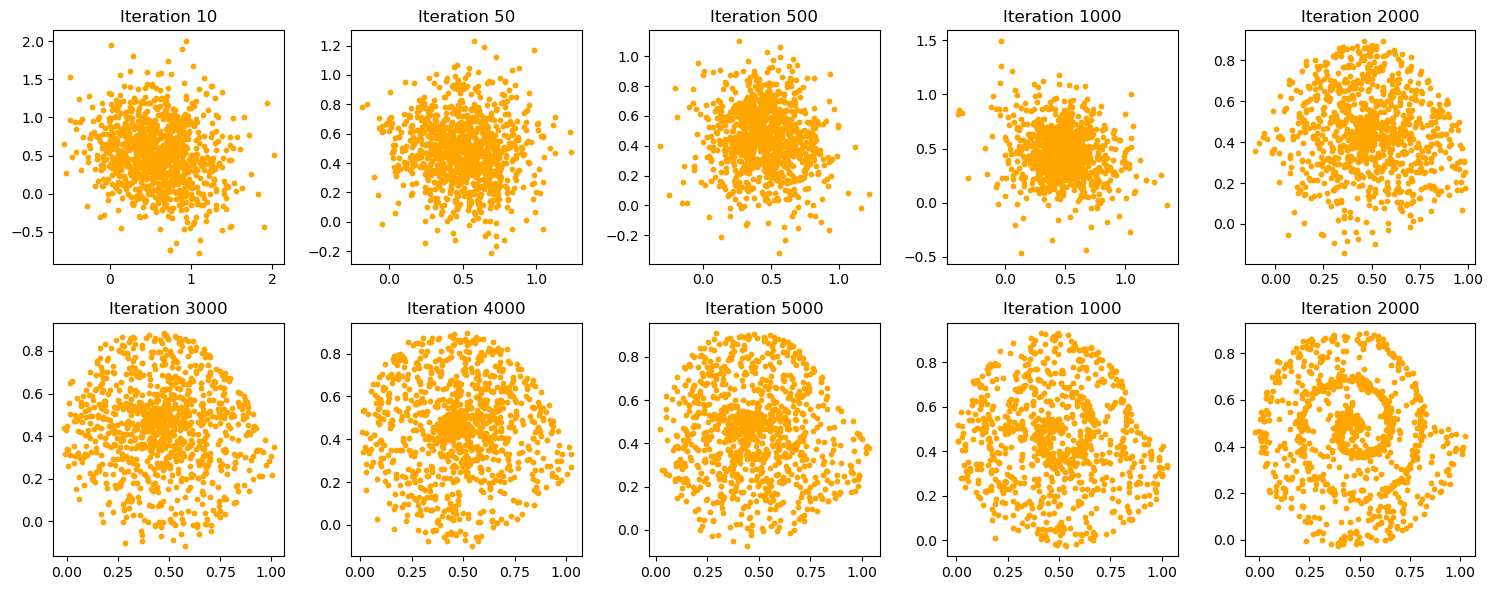

In [217]:
its = [10, 50, 500, 1000, 2000, 3000, 4000, 5000, 10000, 20000]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(len(evolution_mmd)):
    x = evolution_mmd[i][:, 0]
    y = evolution_mmd[i][:, 1]
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

In [222]:
class AffineCoupling(nn.Module):
    """One RealNVP affine coupling layer for 2D data: half the coordinates (given by
    `mask`) pass through unchanged and are used to predict a scale+shift that is
    applied to the other half. Stacking layers with alternating masks makes every
    coordinate get transformed conditioned on the other, while keeping the whole
    map exactly invertible with a cheap-to-compute log-determinant."""
    def __init__(self, mask, hidden=128):
        super().__init__()
        self.register_buffer('mask', mask)
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 4),  # 2 for log_scale, 2 for shift
        )
        # start close to the identity map so training starts stable
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        x_masked = x * self.mask
        log_s, t = self.net(x_masked).chunk(2, dim=1)
        
        # Clamped and restricted to a smaller range for stability
        log_s = torch.tanh(log_s) * 0.5 * (1 - self.mask) 
        t = t * (1 - self.mask)
        
        y = x_masked + (1 - self.mask) * (x * torch.exp(log_s) + t)
        return y, log_s.sum(dim=1)

    def inverse(self, y):
        y_masked = y * self.mask
        log_s, t = self.net(y_masked).chunk(2, dim=1)
        
        # Clamped and restricted to a smaller range for stability
        log_s = torch.tanh(log_s) * 0.5 * (1 - self.mask)
        t = t * (1 - self.mask)
        
        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-log_s))
        return x


class RealNVP(nn.Module):
    def __init__(self, n_layers=16, hidden=128):
        super().__init__()
        masks = [torch.tensor([1., 0.]) if i % 2 == 0 else torch.tensor([0., 1.]) for i in range(n_layers)]
        self.layers = nn.ModuleList([AffineCoupling(m, hidden) for m in masks])

    def forward(self, x):
        """data -> latent, accumulating the log-det-Jacobian for change-of-variables."""
        log_det_total = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            x, log_det = layer(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def inverse(self, z):
        """latent -> data. This is how we generate samples."""
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z

    def log_prob(self, x):
        z, log_det = self.forward(x)
        base_log_prob = -0.5 * (z ** 2).sum(dim=1) - 0.5 * 2 * np.log(2 * np.pi)
        return base_log_prob + log_det

    def sample(self, n):
        z = torch.randn(n, 2, device=next(self.parameters()).device)
        return self.inverse(z)


In [223]:
#ground_truth_flow = (ground_truth - ground_truth.mean(0)) / ground_truth.std(0)

def training_loop_nvp(num_epochs, batch_size=1000, n_layers=16, hidden=128, lr=0.0005):
    flow = RealNVP(n_layers=n_layers, hidden=hidden).to(device)
    optimizer = optim.AdamW(flow.parameters(), lr=lr, weight_decay=1e-5)
    train_losses = []
    print("Training stared")
    special_iterations = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000, 6000]
    q_evolution = []

    for epoch in range(num_epochs + 1):
        flow.train()
        optimizer.zero_grad()

        real_indices = np.random.choice(len(ground_truth_flow), batch_size, replace=False)
        truth_batch = ground_truth_flow[real_indices]

        loss = -flow.log_prob(truth_batch).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)  # coupling layers can spike early on
        optimizer.step()

        epoch_loss = loss.item()
        train_losses.append(epoch_loss)
        if epoch in special_iterations:
            with torch.no_grad():
                generated = flow.sample(1000)
            q_evolution.append(generated.detach().cpu().numpy())
        if epoch % 500 == 0:
            print(f"Epoch [{epoch}/{num_epochs}], NLL: {epoch_loss:.6f}")

    print("Finished")
    return flow, train_losses, q_evolution


In [224]:
flow_trained, losses_flow, evolution_flow = training_loop_nvp(6000)


Training stared
Epoch [0/6000], NLL: 2.850823
Epoch [500/6000], NLL: 2.328561
Epoch [1000/6000], NLL: 1.906468
Epoch [1500/6000], NLL: 1.688499
Epoch [2000/6000], NLL: 1.481692
Epoch [2500/6000], NLL: 2.217985
Epoch [3000/6000], NLL: 1.577700
Epoch [3500/6000], NLL: 1.450258
Epoch [4000/6000], NLL: 1.460701
Epoch [4500/6000], NLL: 1.408423
Epoch [5000/6000], NLL: 1.187204
Epoch [5500/6000], NLL: 1.263531
Epoch [6000/6000], NLL: 1.239491
Finished


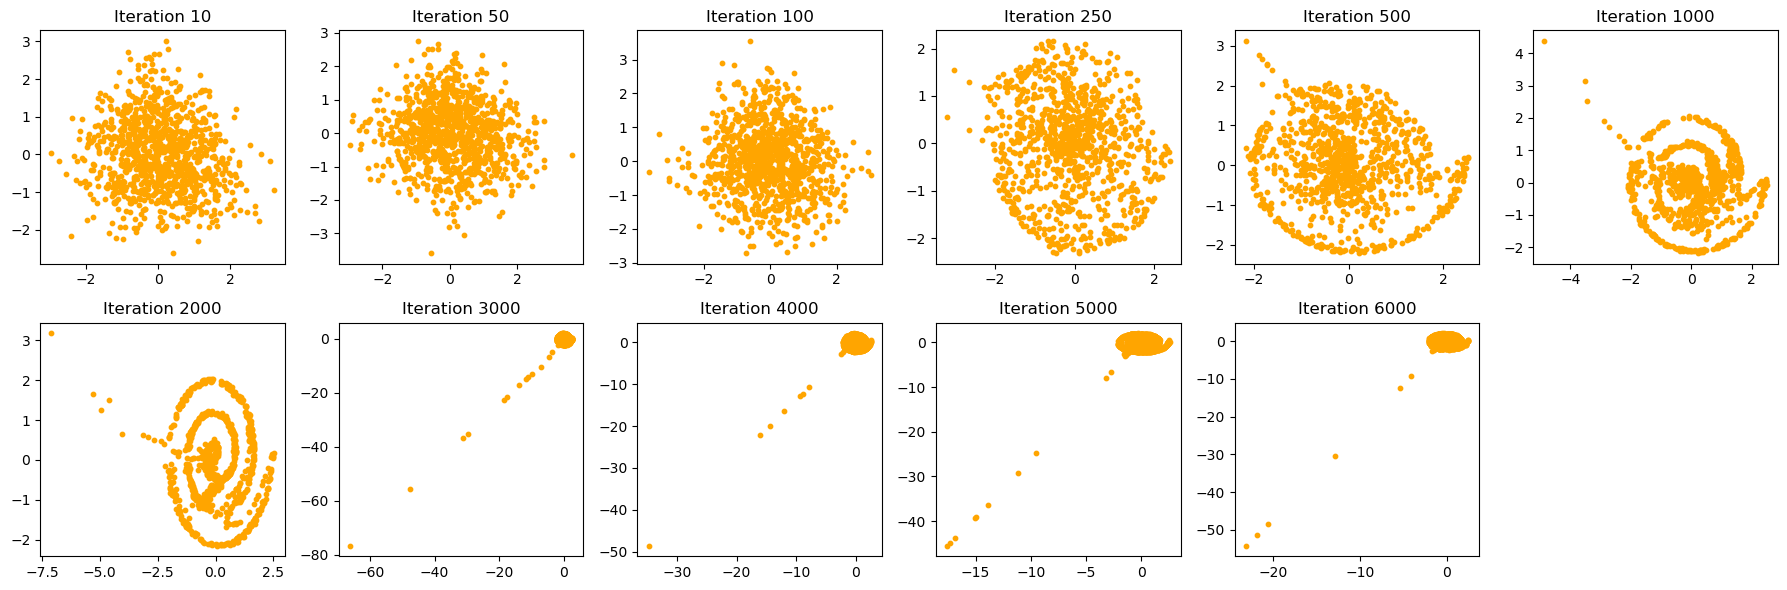

In [228]:
its = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000, 6000]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for i in range(len(evolution_flow)):
    x = evolution_flow[i][:, 0]
    y = evolution_flow[i][:, 1]
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")
for j in range(len(evolution_flow), len(axes)):
    axes[j].axis('off')

plt.tight_layout()

# Comparison between models

In [187]:
import time

def mmd2(x, y, sigmas=(0.05, 0.1, 0.25, 0.5, 1.0)):
    """Same unbiased squared-MMD estimator as the MMD training loss, used here purely as an
    evaluation metric (works regardless of which loss a given method was trained with)."""
    def rbf(a, b):
        dist = torch.cdist(a, b) ** 2
        k = 0.0
        for s in sigmas:
            k = k + torch.exp(-dist / (2 * s ** 2))
        return k
    m, n = x.shape[0], y.shape[0]
    K_xx, K_yy, K_xy = rbf(x, x), rbf(y, y), rbf(x, y)
    return ((K_xx.sum() - K_xx.diag().sum()) / (m * (m - 1))
            + (K_yy.sum() - K_yy.diag().sum()) / (n * (n - 1))
            - 2 * K_xy.sum() / (m * n)).item()

def sinkhorn_distance(x, y, eps=0.01, steps=100):
    """Entropic optimal-transport cost between two point clouds, using the same Sinkhorn
    iteration already implemented for the W-flow method above, as an evaluation metric."""
    n, m = x.shape[0], y.shape[0]
    a = torch.full((n,), 1.0 / n, device=x.device)
    b = torch.full((m,), 1.0 / m, device=x.device)
    cost = 0.5 * torch.cdist(x, y) ** 2
    K = torch.exp(-cost / eps)
    u = torch.ones(n, device=x.device)
    v = torch.ones(m, device=x.device)
    for _ in range(steps):
        u = a / (K @ v + 1e-12)
        v = b / (K.T @ u + 1e-12)
    plan = u.unsqueeze(1) * K * v.unsqueeze(0)
    return torch.sum(plan * cost).item()

def time_call(fn, *args, **kwargs):
    t0 = time.time()
    result = fn(*args, **kwargs)
    return result, time.time() - t0


In [188]:
N_EPOCHS_COMPARE = 2000   # matched training budget for all four methods
BATCH_SIZE_COMPARE = 1000

# --- Drifting model: training_loop() closes over the module-level `f`/`optimizer`/`gaussian`
# defined back in the "Plain drifting" section, so we reset those globals to get a fresh model. ---
f = neuralNet().to(device)
mse = nn.MSELoss()
optimizer = optim.AdamW(f.parameters(), lr=0.001)
(f_drift_cmp, losses_drift_cmp, _), t_train_drift = time_call(training_loop, N_EPOCHS_COMPARE, BATCH_SIZE_COMPARE)

# --- W-flow: `training()` takes the model/reference as arguments, so a fresh call is self-contained. ---
f_wflow_cmp = neuralNet().to(device)
nn.init.orthogonal_(f_wflow_cmp.output.weight)
nn.init.zeros_(f_wflow_cmp.output.bias)
wflow_reference_cmp = torch.from_numpy(np.random.uniform(0, 1, [10000, 32])).float().to(device)
(f_wflow_cmp, losses_wflow_cmp, _), t_train_wflow = time_call(
    training, f_wflow_cmp, wflow_reference_cmp, ground_truth, 0.25, 0.01, N_EPOCHS_COMPARE, BATCH_SIZE_COMPARE
)

# --- MMD and RealNVP are self-contained (they build their own model + optimizer internally). ---
(f_mmd_cmp, losses_mmd_cmp, _), t_train_mmd = time_call(training_loop_mmd, N_EPOCHS_COMPARE, BATCH_SIZE_COMPARE)
(flow_cmp, losses_flow_cmp, _), t_train_flow = time_call(training_loop_nvp, N_EPOCHS_COMPARE, BATCH_SIZE_COMPARE)

print(f"Train time  |  drift: {t_train_drift:7.1f}s   wflow: {t_train_wflow:7.1f}s   "
      f"mmd: {t_train_mmd:7.1f}s   flow: {t_train_flow:7.1f}s")


Training stared
Epoch [0/2000], Loss: 0.000000
Epoch [100/2000], Loss: 0.000021
Epoch [200/2000], Loss: 0.000019
Epoch [300/2000], Loss: 0.000018
Epoch [400/2000], Loss: 0.000016
Epoch [500/2000], Loss: 0.000015
Epoch [600/2000], Loss: 0.000015
Epoch [700/2000], Loss: 0.000013
Epoch [800/2000], Loss: 0.000012
Epoch [900/2000], Loss: 0.000012
Epoch [1000/2000], Loss: 0.000012
Epoch [1100/2000], Loss: 0.000010
Epoch [1200/2000], Loss: 0.000010
Epoch [1300/2000], Loss: 0.000010
Epoch [1400/2000], Loss: 0.000009
Epoch [1500/2000], Loss: 0.000008
Epoch [1600/2000], Loss: 0.000007
Epoch [1700/2000], Loss: 0.000006
Epoch [1800/2000], Loss: 0.000006
Epoch [1900/2000], Loss: 0.000006
Epoch [2000/2000], Loss: 0.000004
Finished
Training stared
Epoch [0/2000], Loss: 0.021076
Epoch [100/2000], Loss: 0.000077
Epoch [200/2000], Loss: 0.000075
Epoch [300/2000], Loss: 0.000097
Epoch [400/2000], Loss: 0.000100
Epoch [500/2000], Loss: 0.000097
Epoch [600/2000], Loss: 0.000129
Epoch [700/2000], Loss: 0.00

In [189]:
def generate_drift(n):
    with torch.no_grad():
        return f_drift_cmp(torch.randn(n, 32, device=device))

def generate_wflow(n):
    with torch.no_grad():
        idx = np.random.choice(len(wflow_reference_cmp), n, replace=(n > len(wflow_reference_cmp)))
        return f_wflow_cmp(wflow_reference_cmp[idx])

def generate_mmd(n):
    with torch.no_grad():
        return f_mmd_cmp(torch.randn(n, 32, device=device))

def generate_flow(n):
    with torch.no_grad():
        # un-standardize back into the same coordinate system as `ground_truth`
        return flow_cmp.sample(n) * ground_truth.std(0) + ground_truth.mean(0)

def evaluate(generate_fn, name, n_samples=1000, timing_repeats=5):
    generate_fn(n_samples)  # warm-up call (allocations, lazy init, etc.)
    times = []
    for _ in range(timing_repeats):
        _, dt = time_call(generate_fn, n_samples)
        times.append(dt)
    samples = generate_fn(n_samples)
    gt_sample = ground_truth[np.random.choice(len(ground_truth), n_samples, replace=False)]
    return {
        "name": name,
        "inf_time": float(np.mean(times)),
        "mmd2_to_gt": mmd2(samples, gt_sample),
        "sinkhorn_to_gt": sinkhorn_distance(samples, gt_sample),
    }

results = []
for name, gen_fn, t_train in [
    ("Drifting", generate_drift, t_train_drift),
    ("W-flow (Sinkhorn)", generate_wflow, t_train_wflow),
    ("MMD", generate_mmd, t_train_mmd),
    ("Normalizing Flow", generate_flow, t_train_flow),
]:
    r = evaluate(gen_fn, name)
    r["train_time"] = t_train
    results.append(r)

for r in results:
    print(f"{r['name']:<20} train={r['train_time']:7.1f}s   "
          f"inference/1000 samples={r['inf_time']*1000:7.2f}ms   "
          f"MMD^2 to GT={r['mmd2_to_gt']:.5f}   Sinkhorn to GT={r['sinkhorn_to_gt']:.5f}")

Drifting             train=   14.4s   inference/1000 samples=   0.79ms   MMD^2 to GT=0.04464   Sinkhorn to GT=0.01131
W-flow (Sinkhorn)    train=  146.5s   inference/1000 samples=   2.10ms   MMD^2 to GT=0.02616   Sinkhorn to GT=0.01007
MMD                  train=   28.5s   inference/1000 samples=   0.62ms   MMD^2 to GT=0.01850   Sinkhorn to GT=0.01034
Normalizing Flow     train=  101.4s   inference/1000 samples=  13.92ms   MMD^2 to GT=0.02862   Sinkhorn to GT=0.00977


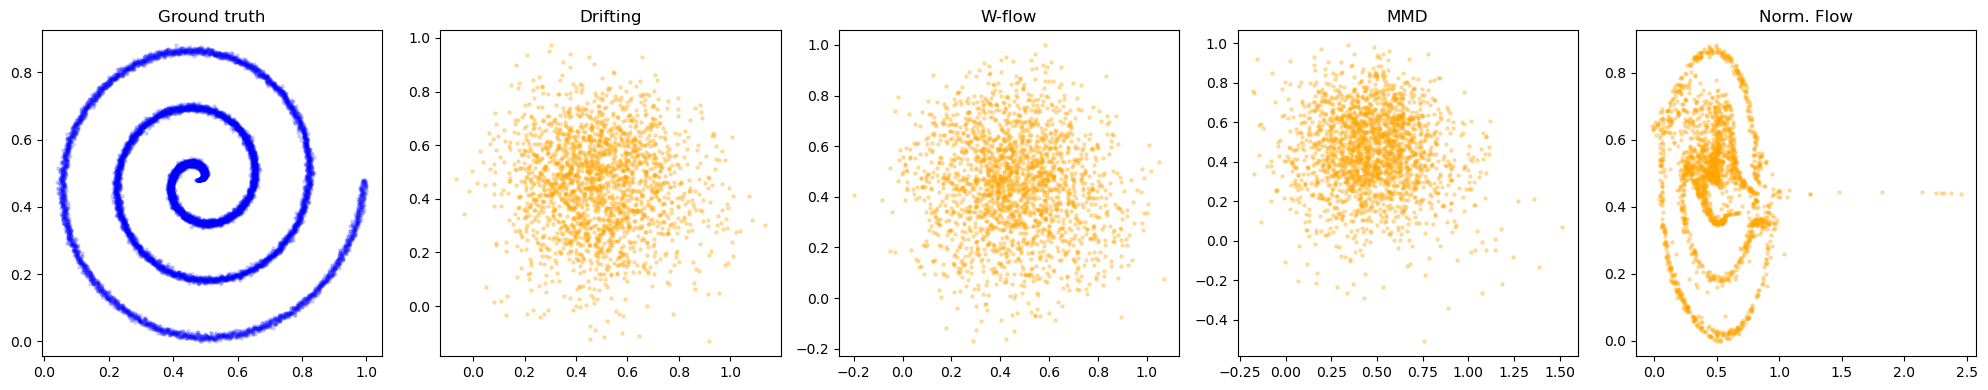

In [190]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
gt_np = ground_truth.cpu().numpy()
axes[0].scatter(gt_np[:, 0], gt_np[:, 1], s=5, alpha=0.15, color='blue')
axes[0].set_title("Ground truth")

for ax, (name, gen_fn) in zip(axes[1:], [
    ("Drifting", generate_drift), ("W-flow", generate_wflow),
    ("MMD", generate_mmd), ("Norm. Flow", generate_flow),
]):
    with torch.no_grad():
        s = gen_fn(2000).cpu().numpy()
    ax.scatter(s[:, 0], s[:, 1], s=5, alpha=0.3, color='orange')
    ax.set_title(name)

plt.tight_layout()


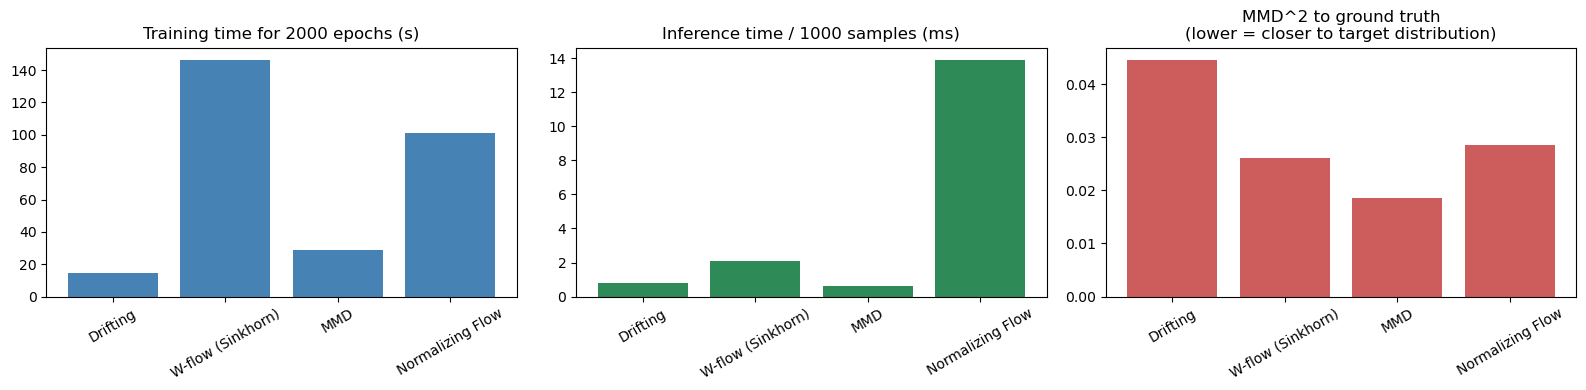

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
names = [r["name"] for r in results]

axes[0].bar(names, [r["train_time"] for r in results], color='steelblue')
axes[0].set_title(f"Training time for {N_EPOCHS_COMPARE} epochs (s)")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(names, [r["inf_time"] * 1000 for r in results], color='seagreen')
axes[1].set_title("Inference time / 1000 samples (ms)")
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(names, [r["mmd2_to_gt"] for r in results], color='indianred')
axes[2].set_title("MMD^2 to ground truth\n(lower = closer to target distribution)")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()


# Using an extra layer and no normalization on ground truth

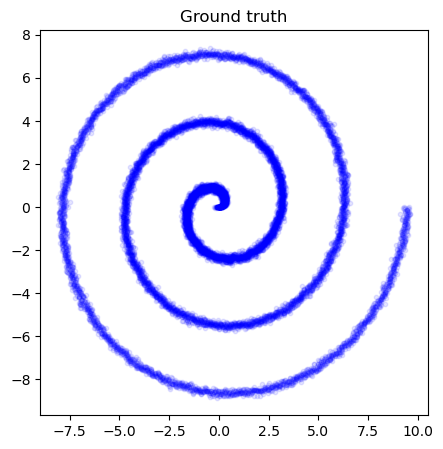

In [289]:
# 1. Spin around 3 times (3 * 2*pi)
theta = np.linspace(0, 3 * 2 * np.pi, 10000)

# Add your noise
noise = np.random.normal(0, 0.1, 10000)

# 2. Radius grows as theta grows. 
# Multiplying by 0.5 controls how tightly coiled the spiral is.
r = (0.5 * theta) + noise 

spiral_x = np.cos(theta) * r
spiral_y = np.sin(theta) * r

ground_truth = np.column_stack([spiral_x, spiral_y])

# CRITICAL FOR YOUR DRIFTING MODEL: 
# Because the spiral gets quite wide at the ends, always normalize it 
# so your neural network doesn't explode when calculating distances!
ground_truth = (ground_truth - np.mean(ground_truth, axis=0)) / np.std(ground_truth, axis=0)


plt.figure(figsize=(5, 5)) 
plt.title("Ground truth")
plt.scatter(spiral_x, spiral_y, s=10, alpha=0.1, color = 'blue')
plt.show()

ground_truth = np.array([list(pair) for pair in zip(spiral_x, spiral_y)])
ground_truth = torch.from_numpy(ground_truth).to(torch.float32).to(device)


In [294]:
class neuralNet(nn.Module):
    def __init__(self):
        # Call the constructor of the parent class (nn.Module)
        super(neuralNet, self).__init__()

        self.input = nn.Linear(32, 258)
        self.initialRelu = nn.SiLU()
        self.layer1 = nn.Linear(258, 258)
        self.relu1 = nn.SiLU()
        self.layer2 = nn.Linear(258, 258)
        self.relu2 = nn.SiLU()
        self.layer3 = nn.Linear(258, 258)
        self.relu3 = nn.SiLU()
        self.output = nn.Linear(258, 2)

    def forward(self, v):
        " v is vector dim 2 (x, y)"
        v = self.input(v)
        v = self.initialRelu(v)
        v = self.layer1(v)
        v = self.relu1(v)
        v = self.layer2(v)
        v = self.relu2(v)
        v = self.layer3(v)
        v = self.relu3(v)
        v = self.output(v)
        return v

In [295]:
# drifting
f = neuralNet()
f_trained, losses, evolution = training_loop(5000)

Training stared
Epoch [0/5000], Loss: 0.000170
Epoch [100/5000], Loss: 0.000172
Epoch [200/5000], Loss: 0.000209
Epoch [300/5000], Loss: 0.000213
Epoch [400/5000], Loss: 0.000161
Epoch [500/5000], Loss: 0.000350
Epoch [600/5000], Loss: 0.000149
Epoch [700/5000], Loss: 0.000174
Epoch [800/5000], Loss: 0.000183
Epoch [900/5000], Loss: 0.000195
Epoch [1000/5000], Loss: 0.000184
Epoch [1100/5000], Loss: 0.000254
Epoch [1200/5000], Loss: 0.000200
Epoch [1300/5000], Loss: 0.000200
Epoch [1400/5000], Loss: 0.000196
Epoch [1500/5000], Loss: 0.000201
Epoch [1600/5000], Loss: 0.000143
Epoch [1700/5000], Loss: 0.000192
Epoch [1800/5000], Loss: 0.000177
Epoch [1900/5000], Loss: 0.000192
Epoch [2000/5000], Loss: 0.000169
Epoch [2100/5000], Loss: 0.000152
Epoch [2200/5000], Loss: 0.000152
Epoch [2300/5000], Loss: 0.000152
Epoch [2400/5000], Loss: 0.000140
Epoch [2500/5000], Loss: 0.000201
Epoch [2600/5000], Loss: 0.000166
Epoch [2700/5000], Loss: 0.000249
Epoch [2800/5000], Loss: 0.000269
Epoch [290

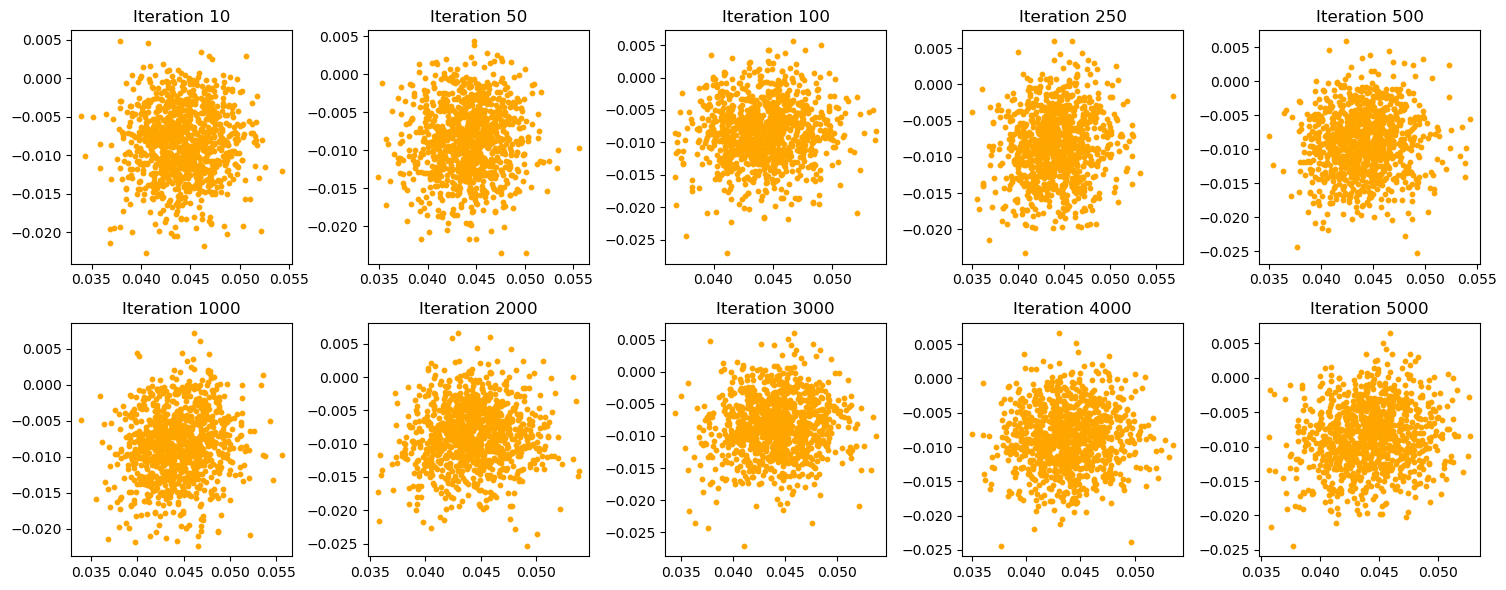

In [296]:
# Using T = 1
its = [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]

fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

In [274]:
# w-flow
f = neuralNet()
nn.init.orthogonal_(f.output.weight)
nn.init.zeros_(f.output.bias)
gaussian = torch.from_numpy(np.random.normal(0, 1, [10000, 32])).float().to(device)
f_trained, losses, evolution = training(f, gaussian, ground_truth, 0.001 , 0.001, 5000)

Training stared
Epoch [0/5000], Loss: 0.0000000003


KeyboardInterrupt: 

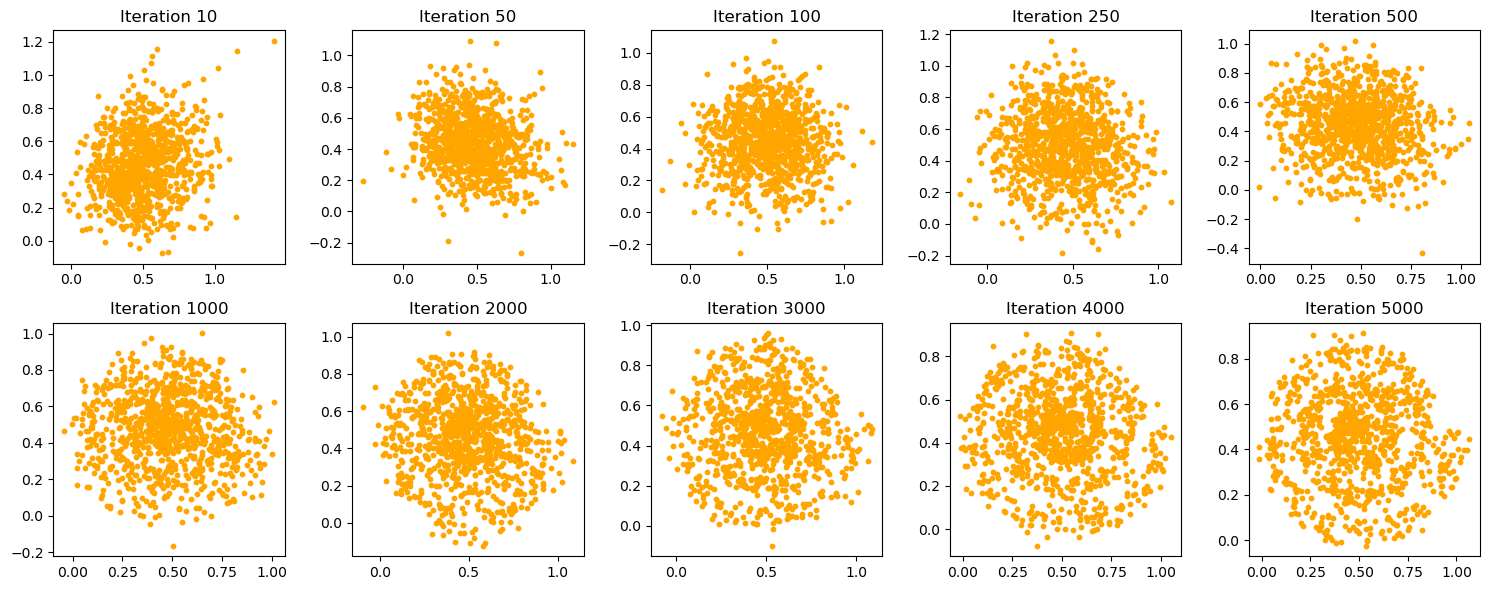

In [261]:
# step and eps: 0.001 , 0.001
its =  [10, 50, 100, 250, 500, 1000,  2000, 3000, 4000, 5000]
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 

# Flatten the 2D axes array to 1D to make iteration simple
axes = axes.flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].set_title(f"Iteration {its[i]}")

plt.tight_layout()

In [227]:
# mmd

In [ ]:
# normalizing flows